### Create the embedding from the py file
1. Upload the images
2. Create the global stats (all the tiles of each product (s1 or s2))
3. Normalize
4. Load the model
5. Use the encoder 
6. Save the .npy

In [1]:
from make_embeddings import (
    embed_image,
    embed_image_joint,
    iter_joint_pairs_from_csv,
    load_model,
    load_or_compute_stats,
)
import numpy as np, glob, re

TILES_ROOT = "../tiles_120px"
CSV_PATH_V3   = "data_csv/v3_images_s2_s1.csv"
FID        = 153    # an example fid
TILE       = 0      # tile
MAX_GAP = 7

# calculate the stats just once
model    = load_model("joint")
s2_stats = load_or_compute_stats(TILES_ROOT, "s2_l2a")
s1_stats = load_or_compute_stats(TILES_ROOT, "s1_grd")


/opt/anaconda3/envs/geo_latest/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#create the joint pairs
from collections import Counter
def check_pairs(FID, CSV_PATH):
    pairs = [p for p in iter_joint_pairs_from_csv(CSV_PATH, TILES_ROOT, max_gap_days=7)
        if p[0] == FID]
    print (pairs)
    print(f"FID {FID}: {len(pairs)} pairs")
    print(f"  Por window: {Counter(p[1] for p in pairs)}")
    print(f"  Gap stats: min={min(p[4] for p in pairs)}, max={max(p[4] for p in pairs)}")

#Number of pairs for version 3
check_pairs(FID, CSV_PATH_V3)

[(153, 'aft', '../tiles_120px/s2_l2a/fid_153/aft/20230520T142719_20230520T142902_T20LNR', '../tiles_120px/s1_grd/fid_153/aft/S1A_IW_GRDH_1SDV_20230521T094912_20230521T094937_048630_05D957_8539', 1), (153, 'aft', '../tiles_120px/s2_l2a/fid_153/aft/20230515T142711_20230515T142713_T20LNR', '../tiles_120px/s1_grd/fid_153/aft/S1A_IW_GRDH_1SDV_20230509T094912_20230509T094937_048455_05D42C_BB80', 6)]
FID 153: 2 pairs
  Por window: Counter({'aft': 2})
  Gap stats: min=1, max=6


In [3]:
# Number of pairs for version 2
CSV_PATH_V2 = "data_csv/v2_images_s2_s1.csv"

check_pairs(FID, CSV_PATH_V2)

[(153, 'aft', '../tiles_120px/s2_l2a/fid_153/aft/20230520T142719_20230520T142902_T20LNR', '../tiles_120px/s1_grd/fid_153/aft/S1A_IW_GRDH_1SDV_20230521T094912_20230521T094937_048630_05D957_8539', 1), (153, 'aft', '../tiles_120px/s2_l2a/fid_153/aft/20230515T142711_20230515T142713_T20LNR', '../tiles_120px/s1_grd/fid_153/aft/S1A_IW_GRDH_1SDV_20230509T094912_20230509T094937_048455_05D42C_BB80', 6)]
FID 153: 2 pairs
  Por window: Counter({'aft': 2})
  Gap stats: min=1, max=6


In [4]:
#Number of pairs for version 1
CSV_PATH_V1 = "data_csv/v1_images_s2_s1.csv"

check_pairs(FID, CSV_PATH_V1)


[(153, 'bef', '../tiles_120px/s2_l2a/fid_153/bef/20230214T142711_20230214T143425_T20LNR', '../tiles_120px/s1_grd/fid_153/bef/S1A_IW_GRDH_1SDV_20230214T094910_20230214T094935_047230_05AAD4_E27D', 0), (153, 'bef', '../tiles_120px/s2_l2a/fid_153/bef/20230420T142719_20230420T142714_T20LNR', '../tiles_120px/s1_grd/fid_153/bef/S1A_IW_GRDH_1SDV_20230415T094911_20230415T094936_048105_05C876_50BE', 5), (153, 'aft', '../tiles_120px/s2_l2a/fid_153/aft/20230520T142719_20230520T142902_T20LNR', '../tiles_120px/s1_grd/fid_153/aft/S1A_IW_GRDH_1SDV_20230521T094912_20230521T094937_048630_05D957_8539', 1), (153, 'aft', '../tiles_120px/s2_l2a/fid_153/aft/20230515T142711_20230515T142713_T20LNR', '../tiles_120px/s1_grd/fid_153/aft/S1A_IW_GRDH_1SDV_20230509T094912_20230509T094937_048455_05D42C_BB80', 6)]
FID 153: 4 pairs
  Por window: Counter({'bef': 2, 'aft': 2})
  Gap stats: min=0, max=6


Gap status means the minimum and maximum day of the joint pairing

In [5]:
model_optical = load_model("optical")
model_sar = load_model("sar")
model_joint = load_model("joint")

In [6]:
# Generate embeddings for all FID pairs in the 3 modalities
pairs = [p for p in iter_joint_pairs_from_csv(CSV_PATH_V3, TILES_ROOT, max_gap_days=MAX_GAP)
        if p[0] == FID]
print(f"FID {FID}: {len(pairs)} pairs with gap <= {MAX_GAP} days")

# S2: used all the images (IT NEEDS TO BE CHANGE FOR CSV VERSION)
s2_dirs = sorted(glob.glob(f"{TILES_ROOT}/s2_l2a/fid_{FID}/*/*"))   # bef + evt + aft, todos los image_ids
for d in s2_dirs:
        embed_image(d, model=model_optical, stats=s2_stats)

# S1: Used all the images 
s1_dirs = sorted(glob.glob(f"{TILES_ROOT}/s1_grd/fid_{FID}/*/*"))
for d in s1_dirs:
        embed_image(d, model=model_sar, stats=s1_stats)

# Create the joint embeddings based on the CSV version 3
for fid, win, s2_dir, s1_dir, gap in iter_joint_pairs_from_csv(
        CSV_PATH_V3, TILES_ROOT, max_gap_days=MAX_GAP):
        if fid != FID: continue
        embed_image_joint(s2_dir, s1_dir, model=model_joint,
                s2_stats=s2_stats, s1_stats=s1_stats)

FID 153: 2 pairs with gap <= 7 days
[done] All embeddings already exist in /Users/angelicamariamorenorojas/Desktop/Master/thesis/tropical_forest_disturbance/embeddings/s2_l2a/fid_153/aft/20230515T142711_20230515T142713_T20LNR
[done] All embeddings already exist in /Users/angelicamariamorenorojas/Desktop/Master/thesis/tropical_forest_disturbance/embeddings/s2_l2a/fid_153/aft/20230520T142719_20230520T142902_T20LNR
[done] All embeddings already exist in /Users/angelicamariamorenorojas/Desktop/Master/thesis/tropical_forest_disturbance/embeddings/s2_l2a/fid_153/bef/20230214T142711_20230214T143425_T20LNR
[done] All embeddings already exist in /Users/angelicamariamorenorojas/Desktop/Master/thesis/tropical_forest_disturbance/embeddings/s2_l2a/fid_153/bef/20230420T142719_20230420T142714_T20LNR
[done] All embeddings already exist in /Users/angelicamariamorenorojas/Desktop/Master/thesis/tropical_forest_disturbance/embeddings/s1_grd/fid_153/aft/S1A_IW_GRDH_1SDV_20230509T094912_20230509T094937_0484

In [7]:
emb = np.load(f"embeddings/joint/fid_{FID}/aft/20230515T142711_20230515T142713_T20LNR__S1A_IW_GRDH_1SDV_20230509T094912_20230509T094937_048455_05D42C_BB80/tile_0.npy")
print(emb.shape)        # (15, 15, 768)
print(emb.dtype)        # float32
print(emb.min(), emb.max(), emb.mean())
print(emb[0, 0, :10]) 

(15, 15, 768)
float32
-8.669529 11.320987 -0.0009050696
[ 0.0288869   0.15291823 -0.0229084  -0.15789747 -0.6009026   0.91119844
 -0.40768996 -0.10957152  0.56655526 -1.0790912 ]


### Check the tile_0 embeddings in different modes

In [8]:
# check the embeddings per tile 0 in the joint time series 
import glob
paths = sorted(glob.glob(f"embeddings/joint/fid_{FID}/*/*/tile_0.npy"))
for p in paths:
    print(p)

embeddings/joint/fid_153/aft/20230515T142711_20230515T142713_T20LNR__S1A_IW_GRDH_1SDV_20230509T094912_20230509T094937_048455_05D42C_BB80/tile_0.npy
embeddings/joint/fid_153/aft/20230520T142719_20230520T142902_T20LNR__S1A_IW_GRDH_1SDV_20230521T094912_20230521T094937_048630_05D957_8539/tile_0.npy


In [9]:
paths = sorted(glob.glob(f"embeddings/s1_grd/fid_{FID}/*/*/tile_0.npy"))
for p in paths:
    print(p)

embeddings/s1_grd/fid_153/aft/S1A_IW_GRDH_1SDV_20230509T094912_20230509T094937_048455_05D42C_BB80/tile_0.npy
embeddings/s1_grd/fid_153/aft/S1A_IW_GRDH_1SDV_20230521T094912_20230521T094937_048630_05D957_8539/tile_0.npy
embeddings/s1_grd/fid_153/bef/S1A_IW_GRDH_1SDV_20230109T094911_20230109T094936_046705_05993A_671C/tile_0.npy
embeddings/s1_grd/fid_153/bef/S1A_IW_GRDH_1SDV_20230121T094910_20230121T094935_046880_059F24_ED7C/tile_0.npy
embeddings/s1_grd/fid_153/bef/S1A_IW_GRDH_1SDV_20230214T094910_20230214T094935_047230_05AAD4_E27D/tile_0.npy
embeddings/s1_grd/fid_153/bef/S1A_IW_GRDH_1SDV_20230226T094910_20230226T094935_047405_05B0D3_9DE4/tile_0.npy
embeddings/s1_grd/fid_153/bef/S1A_IW_GRDH_1SDV_20230310T094910_20230310T094935_047580_05B6BD_2426/tile_0.npy
embeddings/s1_grd/fid_153/bef/S1A_IW_GRDH_1SDV_20230322T094910_20230322T094935_047755_05BCAD_F524/tile_0.npy
embeddings/s1_grd/fid_153/bef/S1A_IW_GRDH_1SDV_20230415T094911_20230415T094936_048105_05C876_50BE/tile_0.npy
embeddings/s1_grd/f

In [10]:
paths = sorted(glob.glob(f"embeddings/s2_l2a/fid_{FID}/*/*/tile_0.npy"))
for p in paths:
    print(p)

embeddings/s2_l2a/fid_153/aft/20230515T142711_20230515T142713_T20LNR/tile_0.npy
embeddings/s2_l2a/fid_153/aft/20230520T142719_20230520T142902_T20LNR/tile_0.npy
embeddings/s2_l2a/fid_153/bef/20230214T142711_20230214T143425_T20LNR/tile_0.npy
embeddings/s2_l2a/fid_153/bef/20230420T142719_20230420T142714_T20LNR/tile_0.npy


### Plot of the embedding

shape: (15, 15, 768)
min: -4.720113 max: 3.7816815 mean: -0.00032025483


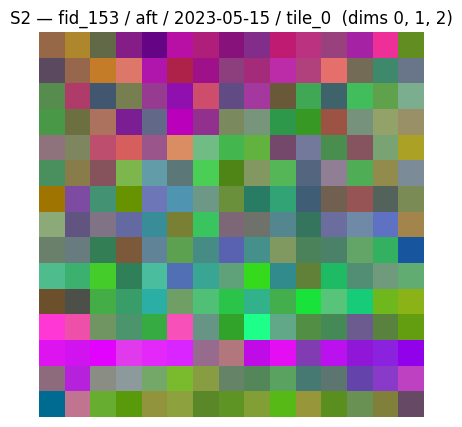

In [11]:
import numpy as np 
import matplotlib.pyplot as plt

emb = np.load("embeddings/s2_l2a/fid_153/aft/20230515T142711_20230515T142713_T20LNR/tile_0.npy")
print("shape:", emb.shape)            # (15, 15, 768)
print("min:", emb.min(), "max:", emb.max(), "mean:", emb.mean())

# First 3 dimensions → RGB, normalized per channel to [0, 1] just for display
rgb = emb[:, :, :3].copy()
for c in range(3):
    ch = rgb[..., c]
    rgb[..., c] = (ch - ch.min()) / (ch.max() - ch.min() + 1e-8)

plt.figure(figsize=(5, 5))
plt.imshow(rgb)
plt.title("S2 — fid_153 / aft / 2023-05-15 / tile_0  (dims 0, 1, 2)")
plt.axis("off")
plt.show()

### Check with the previous embeddings

Created to compare with the embedding created in Charlotte's notebook. That notebook loaded this embedding and proves that they are the same. Here I was trying to visualize it

### Sort the dates

In [12]:
import re, glob

def by_s2_date(p):
    """Extracts the YYYYMMDD from an S2 image_id (path contains '/YYYYMMDDT...')."""
    return re.search(r"/(\d{8})T", p).group(1)

def by_s1_date(p):
    """Extracts the YYYYMMDD from an S1 image_id (path contains '_YYYYMMDDT...')."""
    return re.search(r"_(\d{8})T", p).group(1)

def by_s2_date(p): return re.search(r"/(\d{8})T", p).group(1)
def by_s1_date(p): return re.search(r"_(\d{8})T", p).group(1)

opt_paths   = sorted(glob.glob(f"embeddings/s2_l2a/fid_{FID}/*/*/tile_{TILE}.npy"), key=by_s2_date)
sar_paths   = sorted(glob.glob(f"embeddings/s1_grd/fid_{FID}/*/*/tile_{TILE}.npy"), key=by_s1_date)
joint_paths = sorted(glob.glob(f"embeddings/joint/fid_{FID}/*/*/tile_{TILE}.npy"),  key=by_s2_date)

### Create the time series cubes

In [13]:
cube_opt   = np.stack([np.load(p) for p in opt_paths])
cube_sar   = np.stack([np.load(p) for p in sar_paths])
cube_joint = np.stack([np.load(p) for p in joint_paths])

print(cube_opt.shape)
print(cube_sar.shape)
print(cube_joint.shape)

(4, 15, 15, 768)
(10, 15, 15, 768)
(2, 15, 15, 768)


### Add the shapefile and choose a random pixel to do the time series analysis

In [14]:
import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask

SHP_PATH = "data_shp/label_polygons.shp"

gdf = gpd.read_file(SHP_PATH) 
gdf["fid"] = gdf["fid"].astype(int).astype(str)
poly = gdf[gdf["fid"] == str(FID)].geometry.iloc[0] 

with rasterio.open(sorted(glob.glob(f"{TILES_ROOT}/s2_l2a/fid_{FID}/*/*/tile_{TILE}.tif"))[0]) as src:
    poly_t = gpd.GeoSeries([poly], crs=gdf.crs).to_crs(src.crs).iloc[0]
    mask = geometry_mask([poly_t.__geo_interface__], (src.height, src.width),transform=src.transform, invert=True)

np.random.seed(42)
ys, xs = np.where(mask)
i = np.random.randint(len(ys))
pix_row, pix_col = int(ys[i]), int(xs[i])
token = (pix_row//8, pix_col//8)
print(f"pixel: ({pix_row}, {pix_col})  →  token:({token[0]}, {token[1]})")

pixel: (12, 58)  →  token:(1, 7)


The random token falls inside the image in the original coordinates of 12 from up to down and the 58 from left to right. 

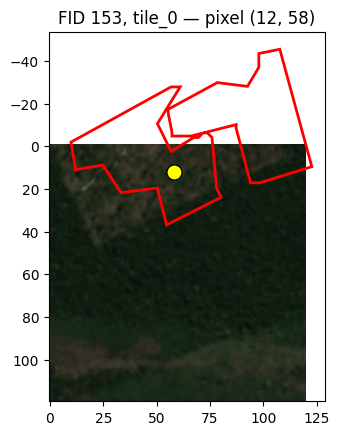

In [15]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon

#glob looks for all the tile_0 with the fid 153, sorted takes the first one
with rasterio.open(sorted(glob.glob(f"{TILES_ROOT}/s2_l2a/fid_{FID}/*/*/tile_{TILE}.tif"))[0]) as src:
    #create the rgb
    rgb = src.read([4, 3, 2]).transpose(1, 2, 0)            # B4, B3, B2 → RGB
    #create the polygon in the pixel coordinates
    poly_pix = [~src.transform * (x, y) for x, y in zip(*poly_t.exterior.xy)]

plt.imshow(rgb / 3000, vmin=0, vmax=1)                       # tile en RGB
plt.gca().add_patch(MplPolygon(poly_pix, fill=False, edgecolor="red", lw=2))
plt.scatter(pix_col, pix_row, c="yellow", s=120, edgecolors="black",
zorder=5)
plt.title(f"FID {FID}, tile_{TILE} — pixel ({pix_row}, {pix_col})")
plt.show()

### Get the time series of each mode (optical, sar and joint) for the random point

In [16]:
ts_opt = cube_opt[:,token[0], token[1], :]
ts_sar = cube_sar[:,token[0], token[1], :]
ts_joint = cube_joint[:,token[0], token[1], :]

print(ts_opt.shape)
print(ts_sar.shape)
print(ts_joint.shape)

(4, 768)
(10, 768)
(2, 768)


### Matrix TxT - Cosine similarity 

In [17]:
import pandas as pd
dates_sar = pd.to_datetime([by_s1_date(p) for p in sar_paths])

#attach the window to the date
def by_win(p):
      return re.search(r"/(bef|evt|aft)/", p).group(1)

wins_sar   = [by_win(p) for p in sar_paths]
labels_sar = [f"{d.strftime('%Y-%m-%d')} ({w})" for d, w in zip(dates_sar, wins_sar)]

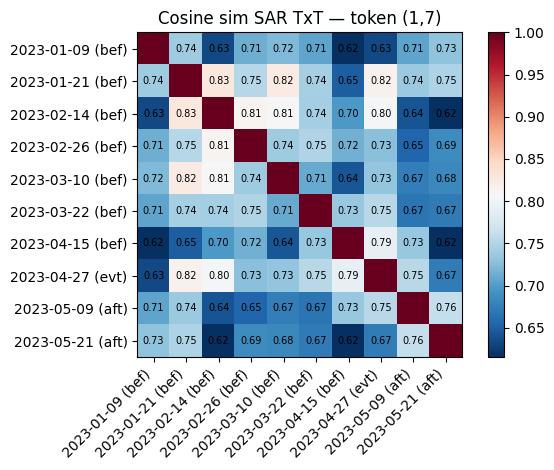

In [18]:
from sklearn.preprocessing import normalize

X = normalize(ts_sar, axis=1)         # (T, 768) normalizado
S = X @ X.T                            # (T, T) cosine sim

vmin, vmax = np.percentile(S, 1), np.percentile(S, 99) #should I do this?
plt.imshow(S, vmin=vmin, vmax=vmax, cmap="RdBu_r")
for i in range(S.shape[0]):
        for j in range(S.shape[1]):
            if i != j:
                plt.text(j, i, f"{S[i,j]:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(); plt.title(f"Cosine sim SAR TxT — token ({token[0]},{token[1]})")
plt.title(f"Cosine sim SAR TxT — token ({token[0]},{token[1]})")
plt.xticks(range(len(labels_sar)), labels_sar, rotation=45, ha="right")
plt.yticks(range(len(labels_sar)), labels_sar)
plt.tight_layout()
plt.show()

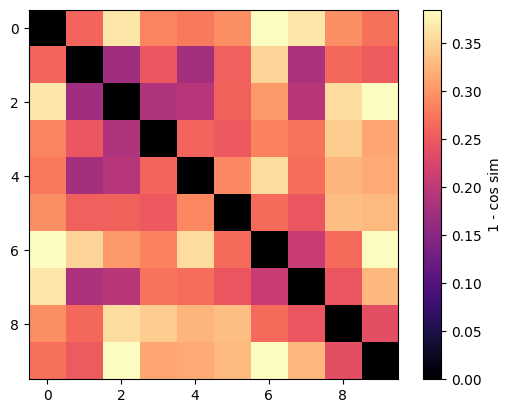

In [19]:
D = 1 - S
plt.imshow(D, cmap="magma")      # secuencial: dark = similar, bright = different
plt.colorbar(label="1 - cos sim")

With the cosine similarities for SAR there is not a clear distintion between the before and after event.

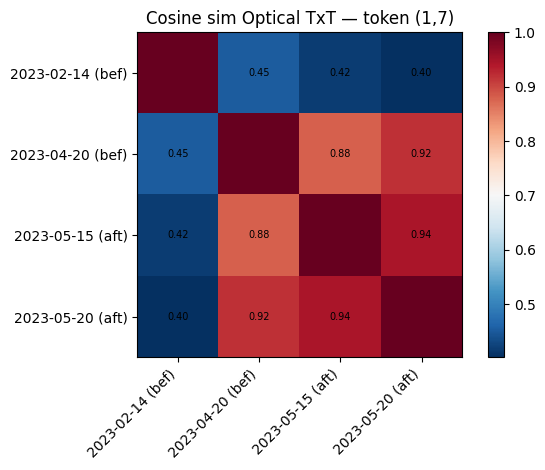

In [20]:
dates_opt  = pd.to_datetime([by_s2_date(p) for p in opt_paths])

def by_win(p):
      return re.search(r"/(bef|evt|aft)/", p).group(1)

wins_opt   = [by_win(p) for p in opt_paths]
labels_opt = [f"{d.strftime('%Y-%m-%d')} ({w})" for d, w in zip(dates_opt, wins_opt)]

X = normalize(ts_opt, axis=1)
S = X @ X.T
vmin, vmax = np.percentile(S, 1), np.percentile(S, 99) 
plt.imshow(S, vmin=vmin, vmax=vmax, cmap="RdBu_r")
#plt.imshow(S, vmin=-1, vmax=1, cmap="RdBu_r")
for i in range(S.shape[0]):
        for j in range(S.shape[1]):
            if i != j:
                plt.text(j, i, f"{S[i,j]:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar()
plt.title(f"Cosine sim Optical TxT — token ({token[0]},{token[1]})")
plt.xticks(range(len(labels_opt)), labels_opt, rotation=45, ha="right")
plt.yticks(range(len(labels_opt)), labels_opt)
plt.tight_layout()
plt.show()

There is also no clear distintion for the optica embeddings. There is not enough pairs for the joint mode which cover bedore and after, there is just after.

### New function which repeat the previous process

This function creates the embeddings

In [21]:
import re, glob
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon


SUBDIRS = {"optical": "s2_l2a", "sar": "s1_grd", "joint": "joint"}


def analyze_token_timeseries(fid, modality, tile=0, seed=42,
                            tiles_root="../tiles_120px",
                            shp_path="data_shp/label_polygons.shp",
                            emb_root="embeddings"):
    subdir = SUBDIRS[modality]
    by_date = lambda p: re.search(r"(\d{8})T", p).group(1) # find the date in the path

    # bring the polygon and create the mask
    gdf = gpd.read_file(shp_path)
    gdf["fid"] = gdf["fid"].astype(int).astype(str)
    poly = gdf[gdf["fid"] == str(fid)].geometry.iloc[0]

    tile_tif = sorted(glob.glob(f"{tiles_root}/s2_l2a/fid_{fid}/*/*/tile_{tile}.tif"))[0]
    with rasterio.open(tile_tif) as src:
        poly_t = gpd.GeoSeries([poly], crs=gdf.crs).to_crs(src.crs).iloc[0]
        mask = geometry_mask([poly_t.__geo_interface__],
                            (src.height, src.width),
                            transform=src.transform, invert=True)
        rgb_tile = src.read([4, 3, 2]).transpose(1, 2, 0)
        poly_pix = [~src.transform * (x, y) for x, y in zip(*poly_t.exterior.xy)]

    np.random.seed(seed)
    ys, xs = np.where(mask)
    i = np.random.randint(len(ys))
    pix_row, pix_col = int(ys[i]), int(xs[i])
    tok_r, tok_c = pix_row // 8, pix_col // 8
    print(f"pixel: ({pix_row}, {pix_col})  →  token:({tok_r},{tok_c})")

    # tile RGB
    plt.imshow(rgb_tile / 3000, vmin=0, vmax=1)
    plt.gca().add_patch(MplPolygon(poly_pix, fill=False, edgecolor="red", lw=2))
    plt.scatter(pix_col, pix_row, c="yellow", s=120, edgecolors="black", zorder=5)
    plt.title(f"FID {fid}, tile_{tile} — pixel ({pix_row}, {pix_col})")
    plt.show()

    # cube + temporal series
    paths = sorted(glob.glob(f"{emb_root}/{subdir}/fid_{fid}/*/*/tile_{tile}.npy"),
                    key=by_date)
    cube = np.stack([np.load(p) for p in paths])
    ts   = cube[:, tok_r, tok_c, :]

    # labels
    dates  = pd.to_datetime([by_date(p) for p in paths])
    wins   = [re.search(r"/(bef|evt|aft)/", p).group(1) for p in paths]
    labels = [f"{d.strftime('%Y-%m-%d')} ({w})" for d, w in zip(dates, wins)]

    # cosine similarity matrix
    X = normalize(ts, axis=1) 
    S = X @ X.T
    #S_off = S.copy(); np.fill_diagonal(S_off, np.nan)
    vmin, vmax = np.nanpercentile(S, [1, 99])

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(S, vmin=vmin, vmax=vmax, cmap="RdBu_r")
    #values of the cosine similarity matrix
    for i in range(S.shape[0]):
        for j in range(S.shape[1]):
            if i != j:
                ax.text(j, i, f"{S[i,j]:.2f}", ha="center", va="center", fontsize=7)
    #labels
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    ax.set_title(f"Cosine sim {modality.upper()} TxT — token ({tok_r},{tok_c})")
    plt.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout(); plt.show()

pixel: (12, 58)  →  token:(1,7)


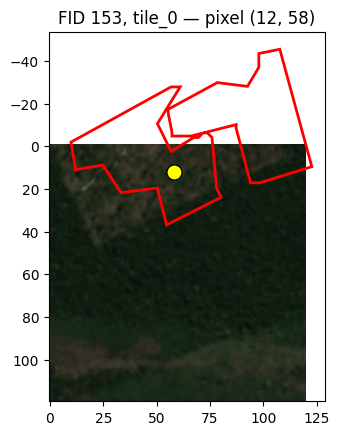

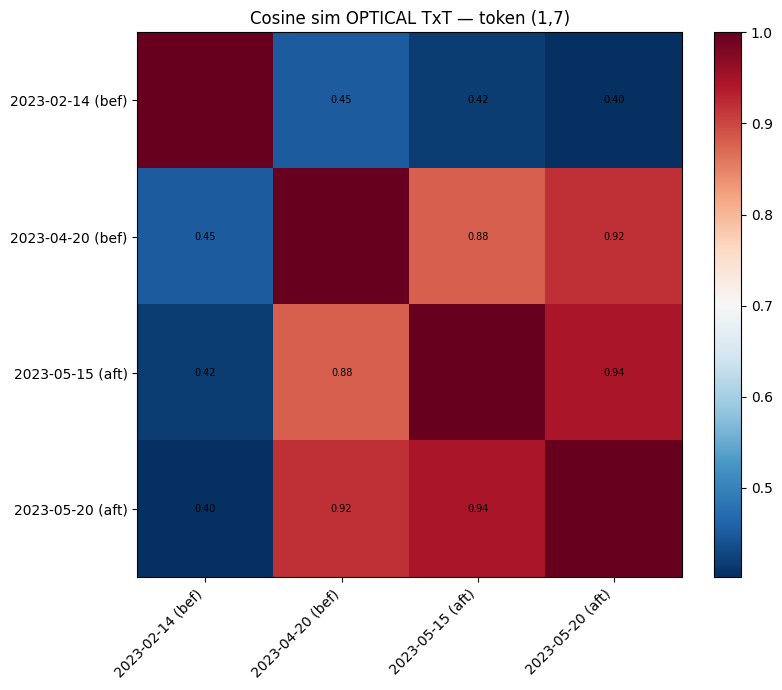

In [22]:
FID = 153
analyze_token_timeseries(FID, "optical", tile=0, seed=42)

pixel: (12, 58)  →  token:(1,7)


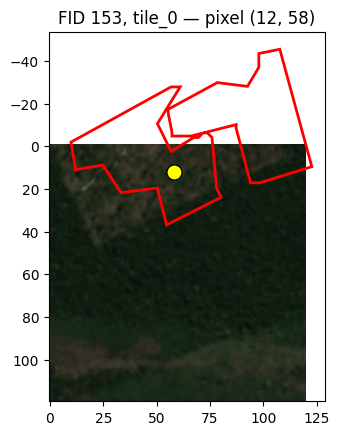

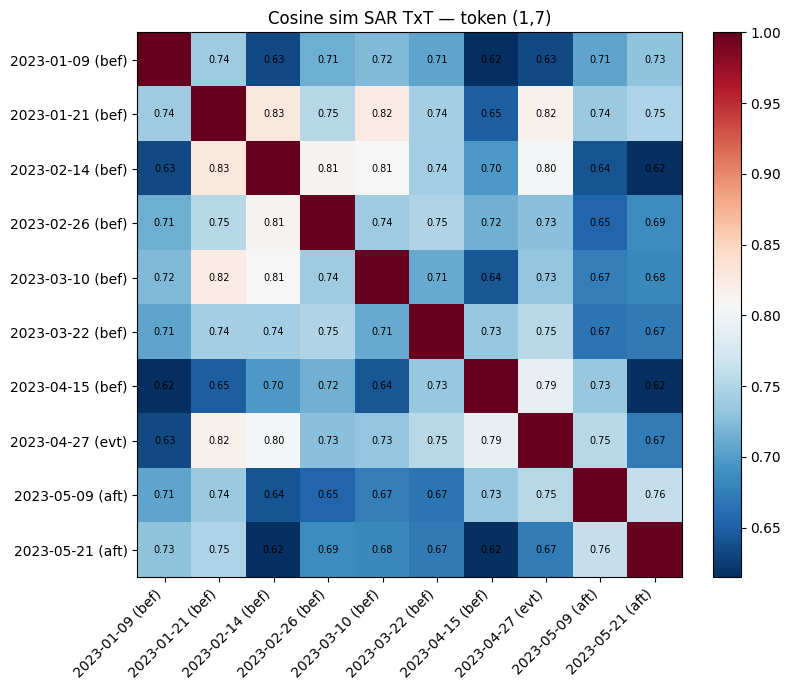

In [23]:
analyze_token_timeseries(FID, "sar", tile=0, seed=42)

pixel: (11, 66)  →  token:(1,8)


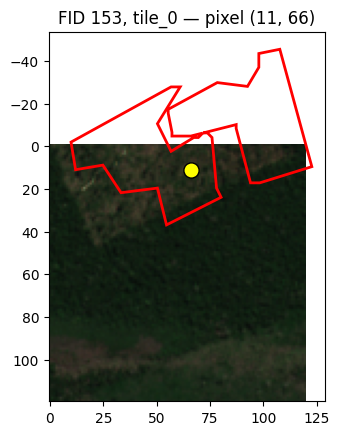

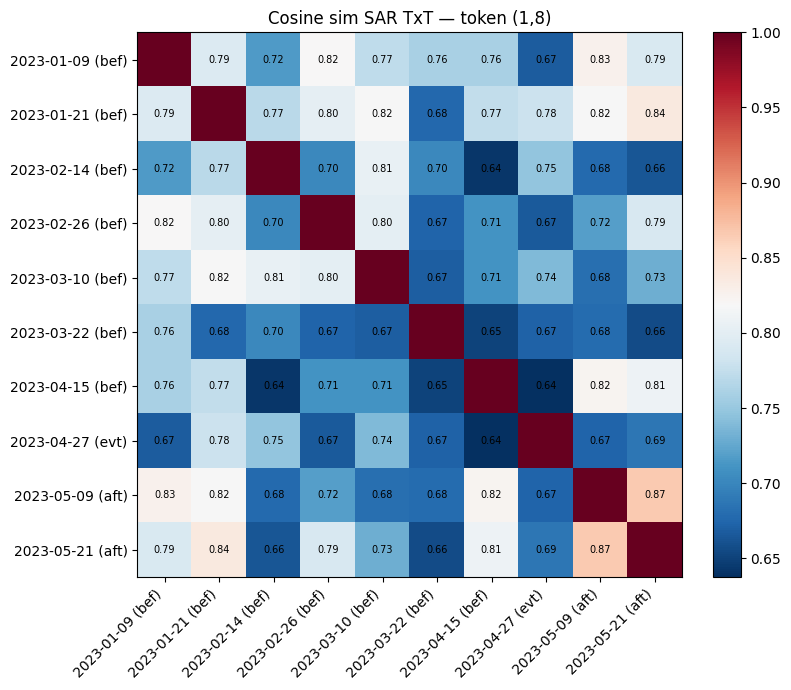

In [24]:
analyze_token_timeseries(FID, "sar", tile=0, seed=1)

pixel: (22, 63)  →  token:(2,7)


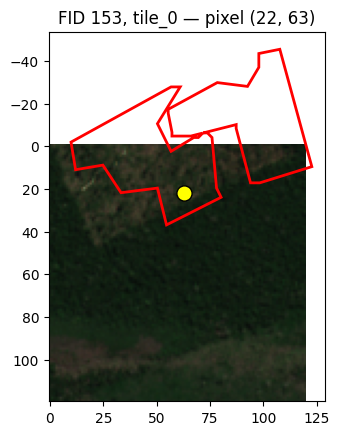

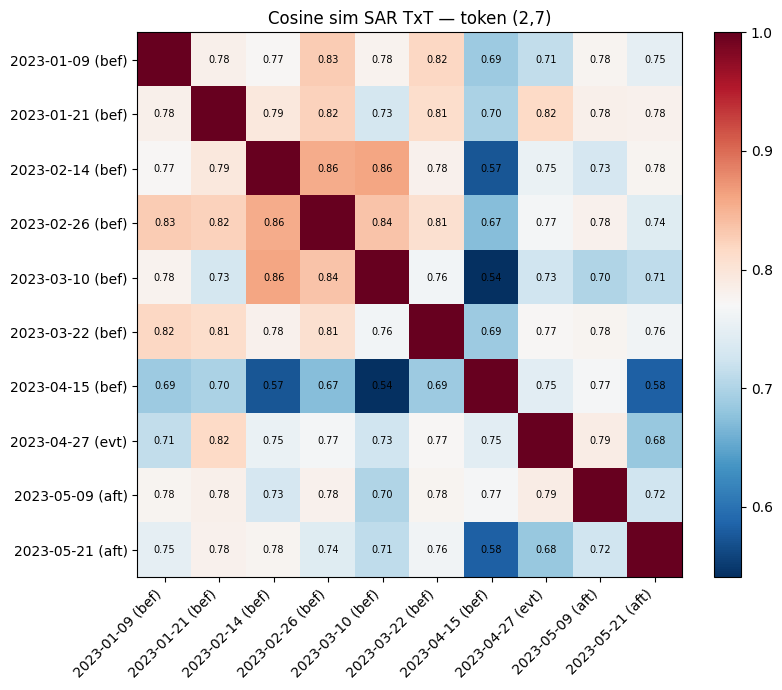

In [25]:
analyze_token_timeseries(FID, "sar", tile=0, seed=19)